In [1]:
import torch
from torch import nn, optim
from unet import Unet, dice_loss
from dataset import dataloader
from aug import load_augmentation
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import json


In [2]:
cwd = Path(os.getcwd()).parent.parent
cwd

WindowsPath('e:/pythonReps')

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2


TARGET_SIZE = (256, 256)  # gewünschte Zielgröße

aug = A.Compose([
    A.Resize(height=TARGET_SIZE[0], width=TARGET_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    ToTensorV2()
])

In [9]:
# parser = argparse.ArgumentParser()
# parser.add_argument("--augmentation", type=str, default="baseline")
# parser.add_argument("--run_name",     type=str, required=True)
# parser.add_argument("--epochs",       type=int, default=100)
# parser.add_argument("--bs",           type=int, default=8)
# parser.add_argument("--lr",           type=float, default=1e-3)
# args = parser.parse_args()
# args = {"augmentation": "baseline"}

img_path      = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/train/img'
mask_path     = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/train/mask'
img_val_path  = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
mask_val_path = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/mask'

out_dir = Path("res") / "test"
out_dir.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# aug = load_augmentation("hist_equilization", ref_dir=img_val_path)

train_dataloader = dataloader(img_path, mask_path, transform=aug, bs=8, shuffle=True, max_samples=50)

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(dataloader, n=4):
    images, masks = next(iter(dataloader))  # einen Batch holen

    fig, axes = plt.subplots(2, n, figsize=(n * 4, 8))
    fig.suptitle("Stichproben aus dem DataLoader", fontsize=14)

    for i in range(n):
        # Bild: (C, H, W) → (H, W, C) für matplotlib
        img = images[i].permute(1, 2, 0).numpy()
        
        # Normalisierung rückgängig machen (falls nötig)
        img = np.clip(img, 0, 1)

        # Maske: (1, H, W) oder (H, W)
        mask = masks[i].squeeze().numpy()

        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Bild {i+1}\n{img.shape}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title(f"Maske {i+1}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataloader, n=4)

KeyError: 'You have to pass data to augmentations as named arguments, for example: aug(image=image)'

In [2]:
import matplotlib.pyplot as plt
trainLoss = [
    1.3848162293434143,
    3.190586268901825,
    1.2804142534732819,
    1.241563618183136,
    1.2063207626342773,
    1.2395729422569275,
    1.1184108257293701,
    1.0973457396030426,
    1.098506972193718,
    1.0036883354187012,
    1.0002213567495346,
    0.9234563112258911,
    1.0012245327234268,
    0.9970742613077164,
    0.9521751254796982,
    1.0486643761396408,
    0.8956235349178314,
    0.8698494881391525,
    0.9775930345058441,
    0.893186628818512,
    0.8495559096336365,
    0.8887229114770889,
    0.8023049831390381,
    1.3008203357458115,
    1.5791929066181183,
    1.1798457503318787,
    0.9839658886194229,
    1.0458176136016846,
    1.064287006855011,
    1.002344086766243,
    0.9945085942745209,
    0.9309847503900528,
    0.9827703833580017,
    0.8804973363876343,
    0.9992045909166336,
    0.9420462846755981,
    0.8692189902067184,
    0.8709424883127213,
    0.9386478364467621,
    0.9025515019893646,
    0.8257092535495758,
    0.8447568863630295,
    0.9029026925563812,
    0.7951523661613464,
    0.9389768838882446,
    0.7777899950742722,
    0.6689546853303909,
    0.713770255446434,
    0.6596469432115555,
    0.6815492659807205,
    0.6951629966497421,
    0.6433007419109344,
    0.664310485124588,
    0.6834217756986618,
    0.6366124600172043,
    0.6149553060531616,
    0.6176365613937378,
    0.60625159740448,
    0.5501859039068222,
    0.6667347103357315,
    0.6859132945537567,
    0.7307466268539429,
    0.7083760648965836,
    0.6031350940465927,
    0.5392421334981918,
    0.7057560309767723,
    0.5568068027496338,
    0.5243000388145447,
    0.658298023045063,
    0.6619915217161179,
    0.6770018637180328,
    0.5401851609349251,
    0.541986271739006,
    0.5709896087646484,
    0.49475617706775665,
    0.631251722574234,
    0.5395257696509361,
    0.579475648701191,
    0.4974437728524208,
    0.4604652225971222,
    0.4978651702404022,
    0.4803067743778229,
    0.6412245631217957,
    0.5517290085554123,
    0.5942346304655075,
    0.6078533828258514,
    0.6046308875083923,
    0.5684232637286186,
    0.6421916633844376,
    0.4944143369793892,
    0.481934055685997,
    0.4874599874019623,
    0.44561585783958435,
    0.47560662031173706,
    0.4246174544095993,
    0.4885287657380104,
    0.4655090272426605,
    0.48108524829149246,
    0.4730215445160866,
    0.5250943228602409
] 
val_loss = [
    2.2814087867736816,
    1.2847855687141418,
    1.297406792640686,
    1.1760637760162354,
    1.0866350531578064,
    1.061460018157959,
    1.0307279229164124,
    0.9870200753211975,
    0.9462750256061554,
    0.9017695188522339,
    0.8788473308086395,
    0.8713782727718353,
    0.8178647756576538,
    0.8155553042888641,
    0.8658393323421478,
    0.8051025867462158,
    0.7548834979534149,
    0.9812504053115845,
    0.8717101216316223,
    0.7022656202316284,
    0.7021936476230621,
    0.6617853939533234,
    0.7234096825122833,
    1.9950310587882996,
    1.2357270121574402,
    0.8902150094509125,
    0.9035313427448273,
    0.9013200104236603,
    0.8497514128684998,
    0.8532722294330597,
    0.8499194979667664,
    0.8211491703987122,
    0.8085417151451111,
    0.8134968280792236,
    0.8089810907840729,
    0.8058754205703735,
    0.7727282345294952,
    0.7541970908641815,
    0.7468310296535492,
    0.7423075139522552,
    0.6534424424171448,
    0.6499941349029541,
    0.6893866062164307,
    0.9149515628814697,
    0.589822381734848,
    0.6367014050483704,
    0.7118637263774872,
    0.5106418281793594,
    0.4989582449197769,
    0.6404921114444733,
    0.5373550057411194,
    0.5010901689529419,
    0.6664374470710754,
    0.5390124619007111,
    0.48418428003787994,
    0.5554710924625397,
    0.5088808983564377,
    0.49350035190582275,
    0.477545827627182,
    0.44197994470596313,
    0.7183763682842255,
    0.46294912695884705,
    0.605182409286499,
    0.45718657970428467,
    0.5916472375392914,
    0.4361129105091095,
    0.4273025244474411,
    0.643036961555481,
    0.5599871575832367,
    0.4472314119338989,
    0.4771448075771332,
    0.4456990957260132,
    0.415519043803215,
    0.42035412788391113,
    0.4210091084241867,
    0.502377837896347,
    0.4769670367240906,
    0.4046126902103424,
    0.40258076786994934,
    0.429033100605011,
    0.3889157921075821,
    0.42928171157836914,
    0.6456537246704102,
    0.42772579193115234,
    0.5620760023593903,
    0.43819181621074677,
    0.4181324690580368,
    0.4780573844909668,
    0.49987268447875977,
    0.41037435829639435,
    0.3902137875556946,
    0.43613624572753906,
    0.3813329190015793,
    0.3667200803756714,
    0.37923187017440796,
    0.4125751703977585,
    0.4372950792312622,
    0.3910363018512726,
    0.40675923228263855,
    0.37910449504852295
]

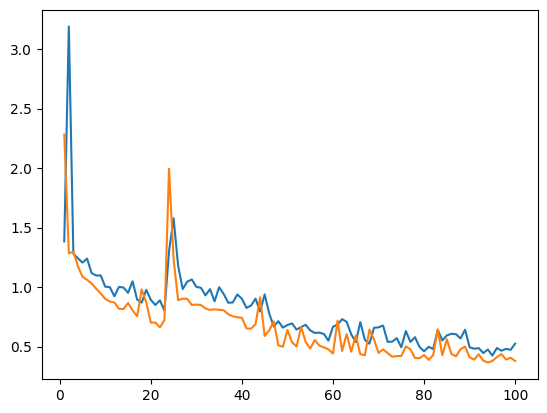

In [4]:
epochs = range(1, 101)
plt.plot(epochs, trainLoss)
plt.plot(epochs, val_loss)
plt.show()